#US Airline Social Media Presence Analysis

In [1]:
!pip install python-dotenv openai emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 13.0 MB/s eta 0:00:00


In [2]:
!pip install torch torchvision torchaudio

In [3]:
#requirements
##Cleaning and Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import regex as re
import emoji
from collections import Counter
import nltk
from nltk.corpus import stopwords

##LLM Call
import os
import openai
from openai import OpenAI
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import json
import dotenv
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
df = pd.read_csv("Tweets.csv")
df.head(10)

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)
5,570300767074181121,negative,1.0000,Can't Tell,0.6842,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica seriously would pay $30 a fligh...,NaN,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada)
6,570300616901320704,positive,0.6745,NaN,0.0000,Virgin America,NaN,cjmcginnis,NaN,0,"@VirginAmerica yes, nearly every time I fly VX...",NaN,2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada)
7,570300248553349120,neutral,0.6340,NaN,NaN,Virgin America,NaN,pilot,NaN,0,@VirginAmerica Really missed a prime opportuni...,NaN,2015-02-24 11:12:29 -0800,Los Angeles,Pacific Time (US & Canada)
8,570299953286942721,positive,0.6559,NaN,NaN,Virgin America,NaN,dhepburn,NaN,0,"@virginamerica Well, I didn't…but NOW I DO! :-D",NaN,2015-02-24 11:11:19 -0800,San Diego,Pacific Time (US & Canada)
9,570295459631263746,positive,1.0000,NaN,NaN,Virgin America,NaN,YupitsTate,NaN,0,"@VirginAmerica it was amazing, and arrived an ...",NaN,2015-02-24 10:53:27 -0800,Los Angeles,Eastern Time (US & Canada)


## Step 1: Exploratory Data Analysis & Data Preparation

In [5]:
print(f'rows,columns: {df.shape}, Data Type: {df.dtypes}')

rows,columns: (14640, 15), Data Type: tweet_id                          int64
airline_sentiment                object
airline_sentiment_confidence    float64
negativereason                   object
negativereason_confidence       float64
airline                          object
airline_sentiment_gold           object
name                             object
negativereason_gold              object
retweet_count                     int64
text                             object
tweet_coord                      object
tweet_created                    object
tweet_location                   object
user_timezone                    object
dtype: object


In [6]:
#missingness
columns = list(df.columns)
na_rows = round((df.isna().sum()/ len(df))*100,2)
na_rows =  na_rows.rename('missing_pct')
na_rows

,missing_pct
tweet_id,0.00
airline_sentiment,0.00
airline_sentiment_confidence,0.00
negativereason,37.31
negativereason_confidence,28.13
airline,0.00
airline_sentiment_gold,99.73
name,0.00
negativereason_gold,99.78
retweet_count,0.00


In [7]:
#remove redundant columns
columns_to_drop = ['airline_sentiment_gold', 'negativereason_gold', 'tweet_coord']
# Drop columns only if they exist
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

# Handle missingness and convert to lowercase for 'negativereason'
# Fill NaN values with a placeholder before calling .str.lower()
df['negativereason'] = df['negativereason'].fillna('not applicable').str.lower()

# Address negativereason for positive and neutral sentiments
# Only modify 'negativereason' where it's 'not applicable' (meaning it was NaN)
# AND the sentiment is 'positive' or 'neutral'
df.loc[(df['airline_sentiment'] == 'positive') & (df['negativereason'] == 'not applicable'), 'negativereason'] = "is positive"
df.loc[(df['airline_sentiment'] == 'neutral') & (df['negativereason'] == 'not applicable'), 'negativereason'] = "is neutral"

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,is neutral,NaN,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,is positive,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,is neutral,NaN,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,bad flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,can't tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [8]:
#rechecking missingness
na_rows = round((df.isna().sum()/ len(df))*100,2)
na_rows =  na_rows.rename('missing_pct')
na_rows

,missing_pct
tweet_id,0.00
airline_sentiment,0.00
airline_sentiment_confidence,0.00
negativereason,0.00
negativereason_confidence,28.13
airline,0.00
name,0.00
retweet_count,0.00
text,0.00
tweet_created,0.00


In [9]:
#duplicates
##unique
total_tweets = len(df)
duplicate_ids = df['tweet_id'].duplicated().sum()
duplicate_users = df['name'].duplicated().sum()
duplicate_tweets = df['text'].duplicated().sum()
repeat_tweets = df[['name','text']].duplicated().sum()

print(f'''\nTotal tweets {total_tweets}, \nNo. of duplicate tweet ids {duplicate_ids},\nNo. of duplicate users {duplicate_users}, \nNo. of duplicate tweets {duplicate_tweets}, \nNo. of duplicate user-tweet combos {repeat_tweets}''')


Total tweets 14640, 
No. of duplicate tweet ids 155,
No. of duplicate users 6939, 
No. of duplicate tweets 213, 
No. of duplicate user-tweet combos 158


In [10]:
#remove duplicate name tweet combos
repeats = df[df[['name','text']].duplicated() == True]
df = df.drop_duplicates(subset=['name', 'text'], keep='first')

In [11]:
#confirming duplicates dropped, originally 14640 rows
df.shape

(14482, 12)

<Figure size 1000x1000 with 0 Axes>

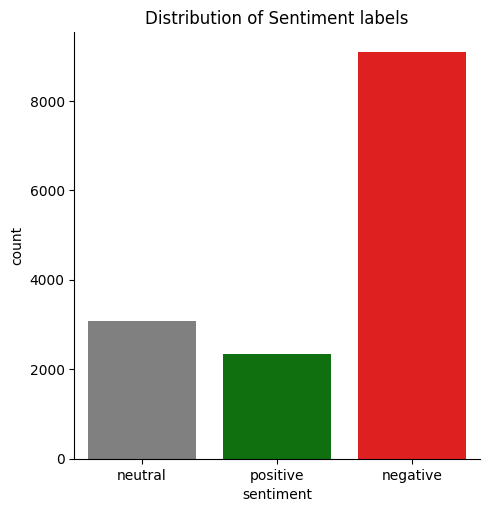

In [12]:
#distribution of sentiment labels
plt.figure(figsize = (10,10))
sentiment_color = {'neutral':'grey', 'positive':'green', 'negative':'red' }
sns.catplot(df, x='airline_sentiment', kind='count', hue='airline_sentiment', palette= sentiment_color)
plt.xlabel('sentiment')
plt.ylabel('count')
plt.title('Distribution of Sentiment labels')
plt.show()

In [13]:
sentiment_df = df.groupby('airline_sentiment')['tweet_id'].count()
sentiment_df

,tweet_id
airline_sentiment,
negative,9081
neutral,3069
positive,2332


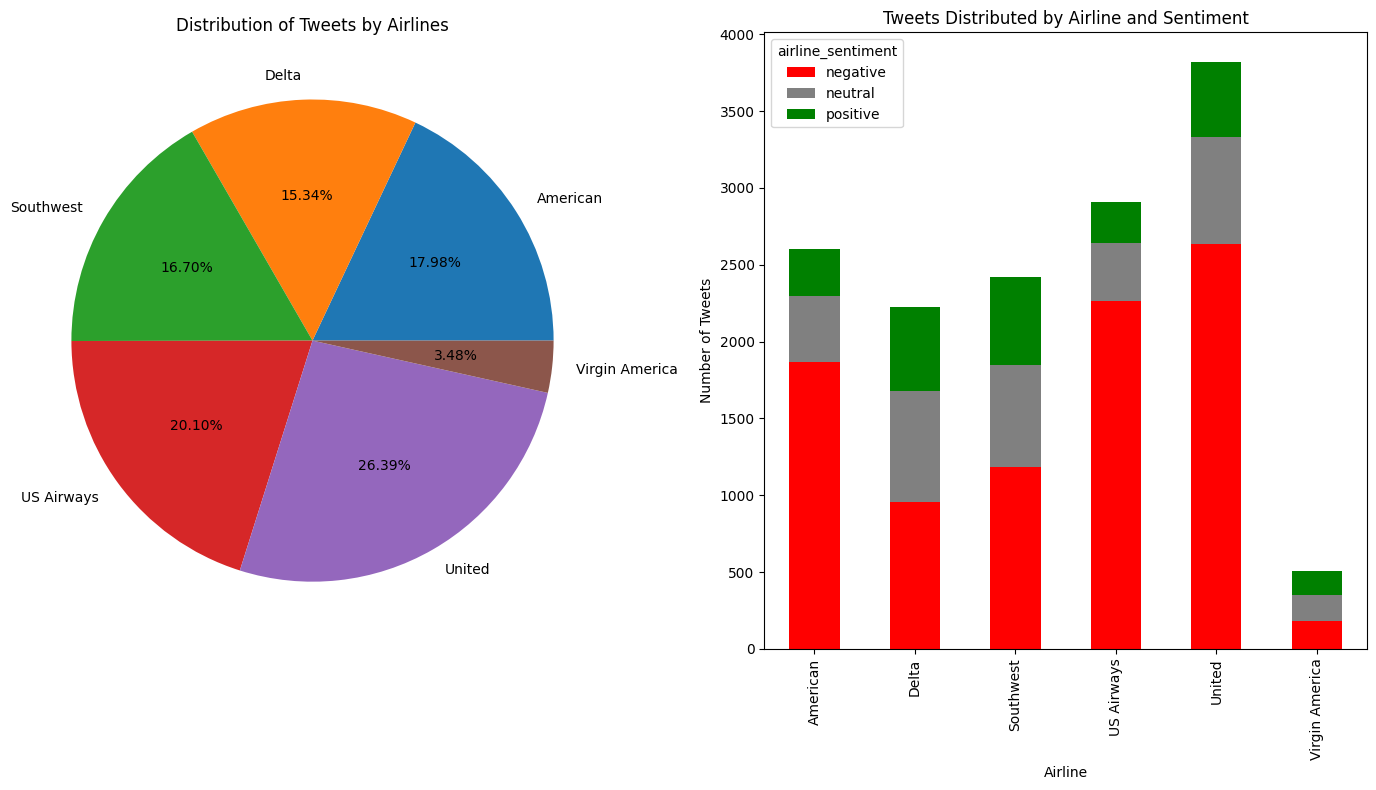

In [14]:
# Distribution of tweets by Airlines
airline = df.groupby('airline').count()
airline
#distribution of sentiments by airlines
airline_dist = df.groupby(['airline', 'airline_sentiment'])['tweet_id'].count().unstack()
#Duo plots
## Airline tweet distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
axes[0].pie(data=airline, x='tweet_id', labels=airline.index, startangle=0, autopct='%.2f%%')
axes[0].set_title('Distribution of Tweets by Airlines')
## airline tweet distribution by sentiment
airline_dist.plot(kind='bar', stacked=True,ax=axes[1], color= sentiment_color)
axes[1].set_title('Tweets Distributed by Airline and Sentiment')
axes[1].set_xlabel("Airline")
axes[1].set_ylabel("Number of Tweets")
axes[1].legend(title="airline_sentiment")
plt.tight_layout()
plt.show()

In [15]:
#airline sentiment distribution
airline_dist.head()

airline_sentiment,negative,neutral,positive
airline,,,
American,1864,433,307
Delta,955,723,544
Southwest,1185,664,570
US Airways,2263,381,267
United,2633,697,492


In [16]:
#tweet cleaning
def clean_text_column(df, column):
  def text_cleaner(text):
    if not isinstance(text, str):
      return str(text)
    ## remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    ## remove mentions
    text = re.sub(r'@\w+', '',text)
    ## remove hastags
    text = re.sub(r'#\w+', '', text)
    ## Excessive punctuation but preserve ! and ?
    text = re.sub(r'[^a-zA-Z0-9\s!?\'\-]', '', text)
    ## Normalizing whitespaces
    text = re.sub(r'\s+',' ', text).strip()
    ## Convert to lowercase
    text = text.lower()

    return text
  ## clean column
  return df[column].apply(text_cleaner)

df['clean_text'] = clean_text_column(df, 'text')

In [17]:
df['clean_text'].head(50)

,clean_text
0,what said
1,plus you've added commercials to the experienc...
2,i didn't today must mean i need to take anothe...
3,it's really aggressive to blast obnoxious ente...
4,and it's a really big bad thing about it
5,seriously would pay 30 a flight for seats that...
6,yes nearly every time i fly vx this ear worm w...
7,really missed a prime opportunity for men with...
8,well i didn'tbut now i do! -d
9,it was amazing and arrived an hour early you'r...


## Step 2: Reason & Theme Analysis

In [18]:
#Look for missing reasons
missing_negs = df[df['airline_sentiment']=='negative'].isna().sum()
missing_negs
## no missing reasons

,0
tweet_id,0
airline_sentiment,0
airline_sentiment_confidence,0
negativereason,0
negativereason_confidence,0
airline,0
name,0
retweet_count,0
text,0
tweet_created,0


In [19]:
# why customers express dissatisfaction by studying the negative reason field
reason2dis = (df[df['airline_sentiment']=='negative'].groupby('negativereason')['tweet_id'].count().reset_index(name='count'))
reason2dis['pct'] = (reason2dis['count']/reason2dis['count'].sum())*100
reason2dis
## we target can't tell and customer service issue as it is too broad

,negativereason,count,pct
0,bad flight,575,6.331902
1,can't tell,1176,12.950116
2,cancelled flight,829,9.128951
3,customer service issue,2884,31.758617
4,damaged luggage,73,0.803876
5,flight attendant complaints,475,5.230701
6,flight booking problems,523,5.759278
7,late flight,1650,18.169805
8,longlines,177,1.949125
9,lost luggage,719,7.917630


In [43]:
# analyze how different types of issues are distributed across airlines and throughout the day
issues_og = df.groupby(['airline','negativereason'])['tweet_id'].count().unstack()
# Normalize to percentages
issuesog_percent = issues_og.div(issues_og.sum(axis=1), axis=0) * 100
# issue distribution
issuesog_dist = df.groupby('negativereason').count()
issuesog_percent

negativereason,bad flight,can't tell,cancelled flight,customer service issue,damaged luggage,flight attendant complaints,flight booking problems,is neutral,is positive,late flight,longlines,lost luggage
airline,,,,,,,,,,,,
American,3.149002,7.066052,8.755760,28.533026,0.422427,3.110599,4.761905,16.628264,11.789555,8.986175,1.267281,5.529954
Delta,2.880288,8.370837,2.295230,8.955896,0.495050,2.700270,1.980198,32.538254,24.482448,12.106211,0.630063,2.565257
Southwest,3.720546,6.572964,6.696982,16.122365,0.578752,1.570897,2.521703,27.449359,23.563456,6.283588,1.198842,3.720546
US Airways,3.572655,8.450704,6.492614,27.859842,0.377877,4.225352,4.191000,13.088286,9.172106,15.561663,1.717623,5.290278
United,5.651491,9.916274,4.735740,17.817896,0.575615,4.395604,3.767661,18.236525,12.872841,13.736264,1.255887,7.038200
Virgin America,3.769841,4.365079,3.571429,11.904762,0.793651,0.992063,5.555556,33.928571,30.158730,3.373016,0.595238,0.992063


In [20]:
load_dotenv("/content/.env.txt")
CACHE_DIR = "cache"
os.makedirs(CACHE_DIR, exist_ok=True)

LLM_PATH = f"{CACHE_DIR}/issue_analysis.json"
CLASS_PATH = f"{CACHE_DIR}/emotion_cache.json"

In [21]:
# use this existing data as a starting point, then fill in missing or ambiguous entries using an LLM
def get_openai_client():
    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        raise ValueError("OPENAI_API_KEY not found")
    return OpenAI(api_key=api_key)


def analyze_reasons(df, batch_size=50, model="gpt-4o-mini", max_tweets_to_process=None):
    results = {}

    # Load existing results from cache if available
    if os.path.exists(LLM_PATH):
        with open(LLM_PATH, 'r') as f:
            try:
                results = json.load(f)
                print(f"Loaded {len(results)} results from cache.")
            except json.JSONDecodeError:
                print("Cache file is corrupted, starting fresh.")
                results = {}

    negative_df = df[df['airline_sentiment'] == 'negative']
    tweets = negative_df[['tweet_id', 'clean_text']].values.tolist()

    if max_tweets_to_process:
        tweets = tweets[:max_tweets_to_process]

    print(f"Processing {len(tweets)} negative tweets...")

    processed_count = 0
    for i in range(0, len(tweets), batch_size):
        batch_tweets = tweets[i:i+batch_size]

        # Filter out tweets already in results
        tweets_to_process_in_batch = []
        for tweet_id, clean_text in batch_tweets:
            if str(tweet_id) not in results:
                tweets_to_process_in_batch.append([tweet_id, clean_text])
            else:
                processed_count += 1

        if not tweets_to_process_in_batch:
            print(f"  Batch {i // batch_size + 1} already in cache. Skipping.")
            continue

        prompt = f"""
        Classify the dissatisfaction reason for each tweet.

        Return ONLY valid JSON:
        tweet_id -> reason

        Allowed reasons:
        Late Flight
        Cancelled Flight
        Lost Luggage
        Booking Issues
        Bad Flight Experience
        Damaged Luggage
        Staff Unprofessional
        Wait Times
        Poor Communication
        Problem Resolution
        Seat Comfort
        In-flight Service
        Pricing Issues
        Website Issues
        Other Issues

        Tweets:
        {tweets_to_process_in_batch}
        """
        print(f"  Processing batch {i // batch_size + 1} of {len(tweets) // batch_size + (1 if len(tweets) % batch_size != 0 else 0)} (new tweets: {len(tweets_to_process_in_batch)})...")

        try:
            response = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                response_format={"type": "json_object"}
            )

            content = response.choices[0].message.content

            batch_result = json.loads(content)
            results.update(batch_result)

            # Save results to cache after each batch
            with open(LLM_PATH, 'w') as f:
                json.dump(results, f)
            print(f"  Saved {len(results)} results to cache.")

        except json.JSONDecodeError as e:
            print(f"Error decoding JSON for batch {i // batch_size + 1}: {e}")
            print("Invalid JSON returned:")
            print(content)
            break # Stop processing on JSON error
        except Exception as e:
            print(f"An API error occurred for batch {i // batch_size + 1}: {e}")
            print("Attempted content:")
            print(content if 'content' in locals() else "No content received.")
            break # Stop processing on other API errors

    if processed_count > 0:
        print(f"Skipped {processed_count} tweets already present in cache.")

    return results

In [22]:
client = get_openai_client()
reasons = analyze_reasons(df)

# Convert 'tweet_id' to string type before mapping to match the dictionary keys
df['LLM_reason'] = df['tweet_id'].astype(str).map(reasons)

# Display the generated reasons and the updated DataFrame head to confirm the output
display(reasons)

Processing 9081 negative tweets...
  Processing batch 1 of 182 (new tweets: 50)...
  Saved 49 results to cache.
  Processing batch 2 of 182 (new tweets: 50)...
  Saved 99 results to cache.
  Processing batch 3 of 182 (new tweets: 50)...
  Saved 149 results to cache.
  Processing batch 4 of 182 (new tweets: 50)...
  Saved 199 results to cache.
  Processing batch 5 of 182 (new tweets: 50)...
  Saved 248 results to cache.
  Processing batch 6 of 182 (new tweets: 50)...
  Saved 298 results to cache.
  Processing batch 7 of 182 (new tweets: 50)...
  Saved 348 results to cache.
  Processing batch 8 of 182 (new tweets: 50)...
  Saved 398 results to cache.
  Processing batch 9 of 182 (new tweets: 50)...
  Saved 448 results to cache.
  Processing batch 10 of 182 (new tweets: 50)...
  Saved 498 results to cache.
  Processing batch 11 of 182 (new tweets: 50)...
  Saved 548 results to cache.
  Processing batch 12 of 182 (new tweets: 50)...
  Saved 597 results to cache.
  Processing batch 13 of 182

{'570301031407624196': 'In-flight Service',
 '570300817074462722': 'Other Issues',
 '570300767074181121': 'Seat Comfort',
 '570282469121007616': 'Website Issues',
 '570276917301137409': 'Seat Comfort',
 '570265883513384960': 'Pricing Issues',
 '570256553502068736': 'Booking Issues',
 '570249102404923392': 'Problem Resolution',
 '570239632807370753': 'Poor Communication',
 '570207886493782019': 'In-flight Service',
 '570114021854212096': 'Booking Issues',
 '570088404156698625': 'Lost Luggage',
 '570084582780899328': 'Problem Resolution',
 '570035876845084672': 'Website Issues',
 '570025482344898560': 'Booking Issues',
 '569996412286582784': 'Website Issues',
 '569989034501500928': 'Problem Resolution',
 '569976620158578688': 'Wait Times',
 '569973821396152323': 'Wait Times',
 '569967019958730753': 'Lost Luggage',
 '569946362126602240': 'Other Issues',
 '569935232033366017': 'Staff Unprofessional',
 '569933816963342337': 'Wait Times',
 '569933405506310144': 'Cancelled Flight',
 '56992924

In [23]:
display(df.head(10))

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,name,retweet_count,text,tweet_created,tweet_location,user_timezone,clean_text,LLM_reason
0,570306133677760513,neutral,1.0000,is neutral,NaN,Virgin America,cairdin,0,@VirginAmerica What @dhepburn said.,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada),what said,NaN
1,570301130888122368,positive,0.3486,is positive,0.0000,Virgin America,jnardino,0,@VirginAmerica plus you've added commercials t...,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada),plus you've added commercials to the experienc...,NaN
2,570301083672813571,neutral,0.6837,is neutral,NaN,Virgin America,yvonnalynn,0,@VirginAmerica I didn't today... Must mean I n...,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada),i didn't today must mean i need to take anothe...,NaN
3,570301031407624196,negative,1.0000,bad flight,0.7033,Virgin America,jnardino,0,@VirginAmerica it's really aggressive to blast...,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada),it's really aggressive to blast obnoxious ente...,In-flight Service
4,570300817074462722,negative,1.0000,can't tell,1.0000,Virgin America,jnardino,0,@VirginAmerica and it's a really big bad thing...,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada),and it's a really big bad thing about it,Other Issues
5,570300767074181121,negative,1.0000,can't tell,0.6842,Virgin America,jnardino,0,@VirginAmerica seriously would pay $30 a fligh...,2015-02-24 11:14:33 -0800,NaN,Pacific Time (US & Canada),seriously would pay 30 a flight for seats that...,Seat Comfort
6,570300616901320704,positive,0.6745,is positive,0.0000,Virgin America,cjmcginnis,0,"@VirginAmerica yes, nearly every time I fly VX...",2015-02-24 11:13:57 -0800,San Francisco CA,Pacific Time (US & Canada),yes nearly every time i fly vx this ear worm w...,NaN
7,570300248553349120,neutral,0.6340,is neutral,NaN,Virgin America,pilot,0,@VirginAmerica Really missed a prime opportuni...,2015-02-24 11:12:29 -0800,Los Angeles,Pacific Time (US & Canada),really missed a prime opportunity for men with...,NaN
8,570299953286942721,positive,0.6559,is positive,NaN,Virgin America,dhepburn,0,"@virginamerica Well, I didn't…but NOW I DO! :-D",2015-02-24 11:11:19 -0800,San Diego,Pacific Time (US & Canada),well i didn'tbut now i do! -d,NaN
9,570295459631263746,positive,1.0000,is positive,NaN,Virgin America,YupitsTate,0,"@VirginAmerica it was amazing, and arrived an ...",2015-02-24 10:53:27 -0800,Los Angeles,Eastern Time (US & Canada),it was amazing and arrived an hour early you'r...,NaN


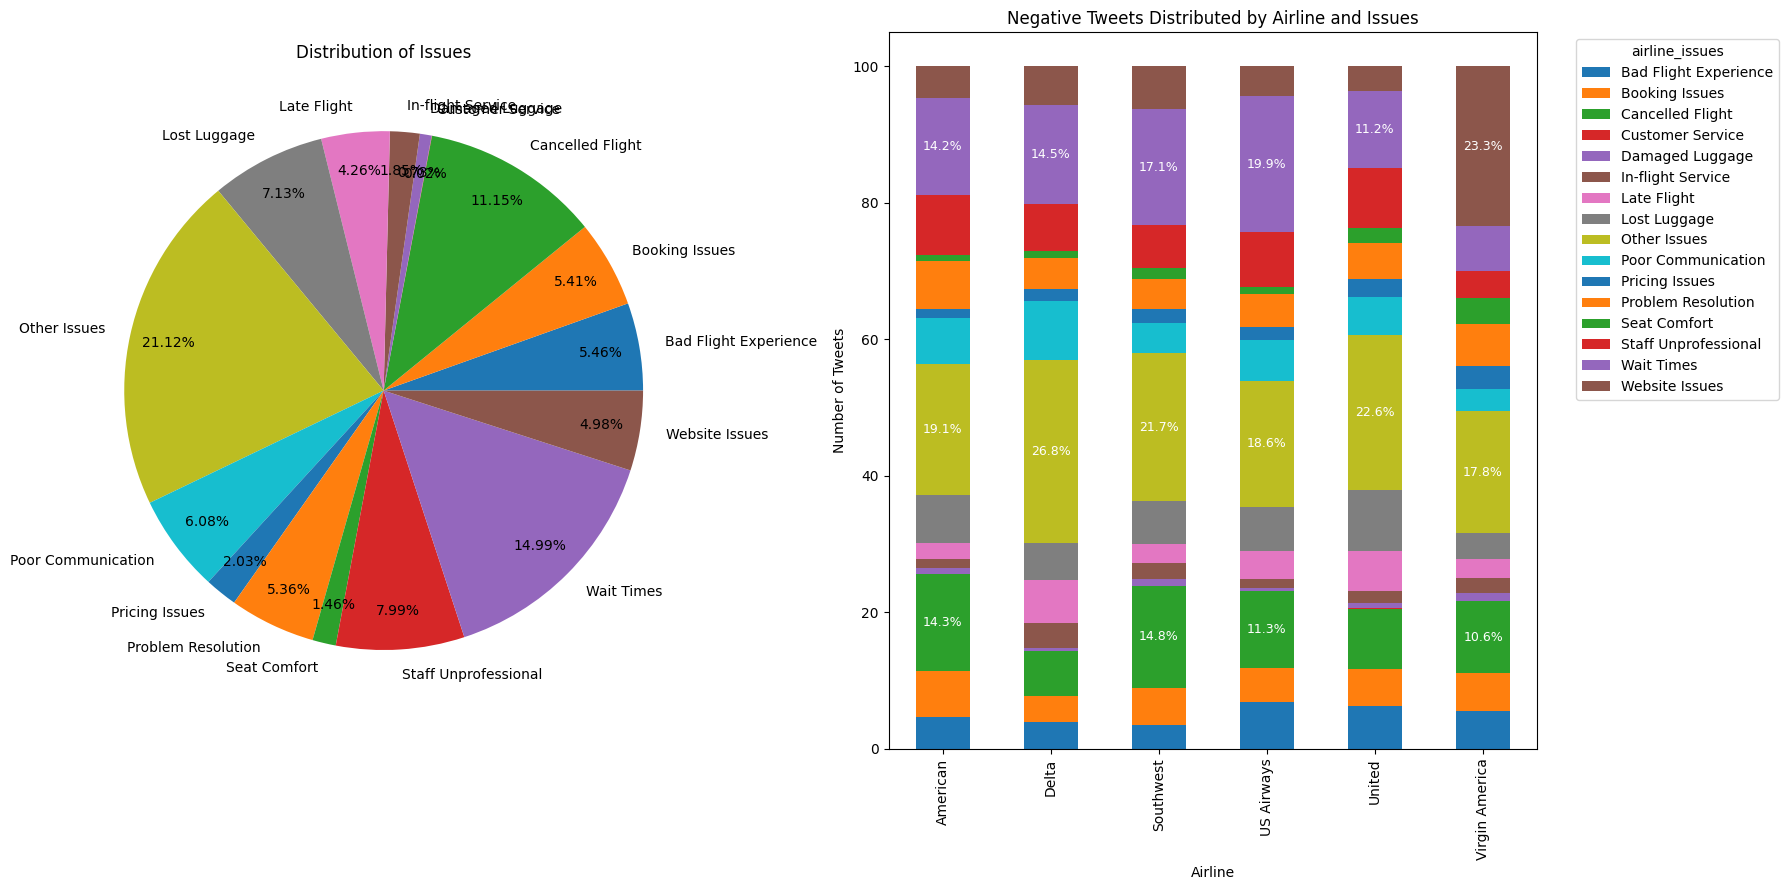

In [26]:
# analyze how different types of issues are distributed across airlines and throughout the day
issues_df = df.groupby(['airline','LLM_reason'])['tweet_id'].count().unstack()
# Normalize to percentages
issues_percent = issues_df.div(issues_df.sum(axis=1), axis=0) * 100
# issue distribution
issues_dist = df.groupby('LLM_reason').count()
## visualize patterns
fig, axes = plt.subplots(1, 2, figsize=(18, 9)) # Increased figure size
axes[0].pie(data=issues_dist, x='tweet_id', labels=issues_dist.index, startangle=0, autopct='%.2f%%', pctdistance=0.85)
axes[0].set_title('Distribution of Issues')
### Issues
issues_percent.plot(kind='bar', stacked=True,ax=axes[1])
axes[1].set_title('Negative Tweets Distributed by Airline and Issues')
axes[1].set_xlabel("Airline")
axes[1].set_ylabel("Number of Tweets")
axes[1].legend(title="airline_issues", bbox_to_anchor=(1.05, 1), loc='upper left') # Adjusted legend position
### Add data labels only if >10%
for p in axes[1].patches:
    width, height = p.get_width(), p.get_height()
    if height > 10:  # show only if segment >10%
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2
        axes[1].text(x, y, f'{height:.1f}%', ha='center', va='center', fontsize=9, color='white')
plt.tight_layout()
plt.show()

In [27]:
#issue distribution by airline
issues_df

LLM_reason,Bad Flight Experience,Booking Issues,Cancelled Flight,Customer Service,Damaged Luggage,In-flight Service,Late Flight,Lost Luggage,Other Issues,Poor Communication,Pricing Issues,Problem Resolution,Seat Comfort,Staff Unprofessional,Wait Times,Website Issues
airline,,,,,,,,,,,,,,,,
American,87.0,123.0,264.0,NaN,15.0,25.0,44.0,130.0,353.0,127.0,23.0,131.0,16.0,162.0,262.0,86.0
Delta,37.0,37.0,62.0,NaN,5.0,35.0,60.0,51.0,255.0,83.0,17.0,43.0,10.0,65.0,138.0,54.0
Southwest,41.0,65.0,175.0,NaN,12.0,29.0,32.0,74.0,256.0,52.0,25.0,52.0,18.0,74.0,202.0,73.0
US Airways,154.0,112.0,255.0,NaN,11.0,29.0,91.0,145.0,418.0,135.0,40.0,111.0,23.0,181.0,447.0,99.0
United,164.0,142.0,232.0,2.0,21.0,45.0,153.0,237.0,594.0,146.0,72.0,136.0,58.0,233.0,293.0,96.0
Virgin America,10.0,10.0,19.0,NaN,2.0,4.0,5.0,7.0,32.0,6.0,6.0,11.0,7.0,7.0,12.0,42.0


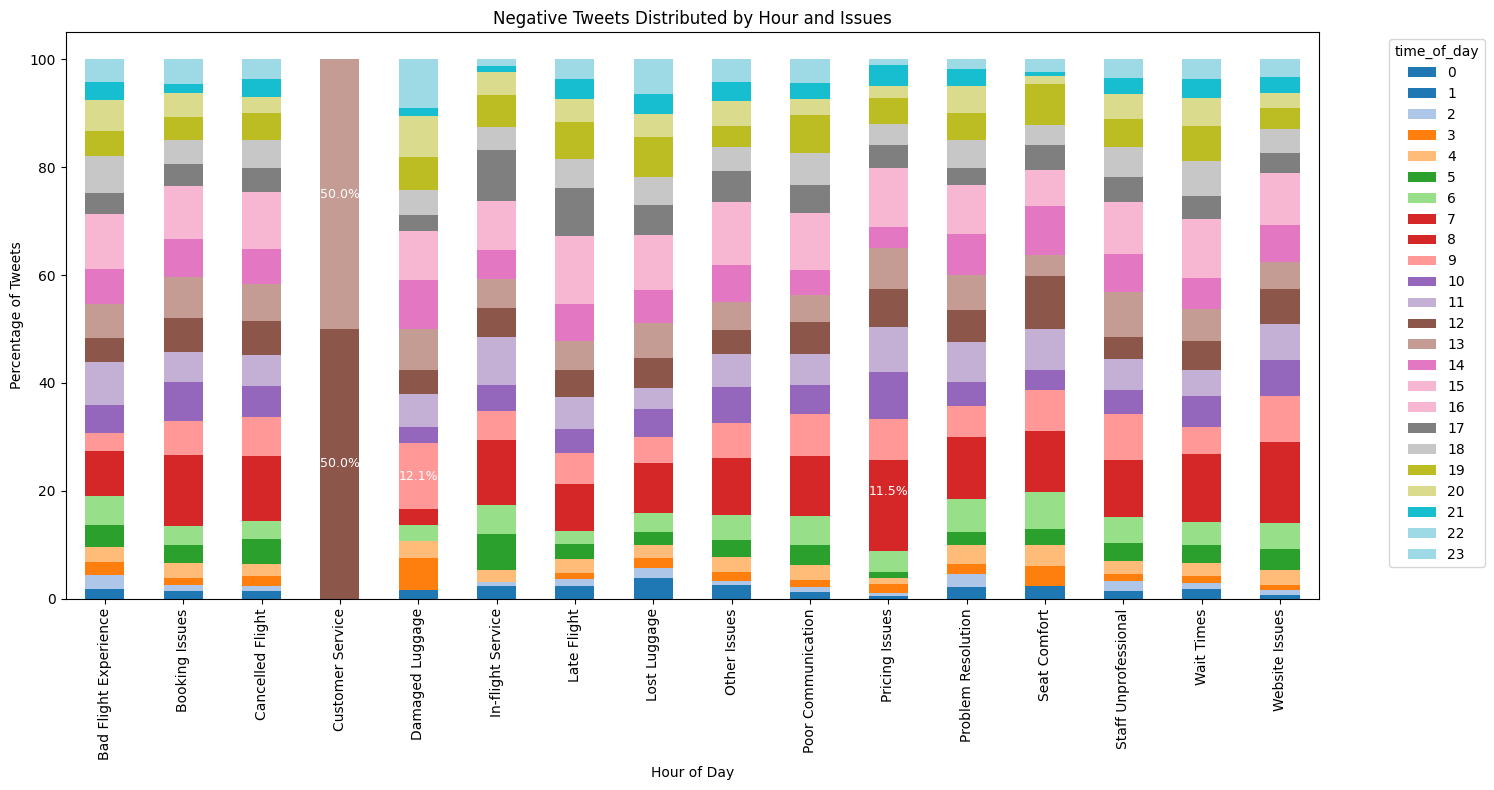

In [28]:
#issue distribution by time
df['timestamp'] = pd.to_datetime(df['tweet_created'])
df['hour'] = df['timestamp'].dt.hour
hour_dist = df.groupby(['LLM_reason','hour'])['tweet_id'].count().unstack()
hour_percent = hour_dist.div(hour_dist.sum(axis=1), axis=0) * 100
## visualization
n = len(hour_percent.columns)
colors = plt.cm.tab20(np.linspace(0, 1, n))
### Issues by Hour
fig, ax = plt.subplots(figsize=(15,8))
hour_percent.plot(kind='bar', stacked=True, ax=ax, color=colors)
ax.set_title('Negative Tweets Distributed by Hour and Issues')
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Percentage of Tweets")
ax.legend(title="time_of_day", bbox_to_anchor=(1.05, 1), loc='upper left')
#### Add data labels only if >10%
for p in ax.patches: # Iterate over patches of the current ax
    width, height = p.get_width(), p.get_height()
    if height > 10:  # show only if segment >10%
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2
        ax.text(x, y, f'{height:.1f}%', ha='center', va='center', fontsize=9, color='white') # Use ax.text
plt.tight_layout()
plt.show()

,afternoon,evening,night,midnight,morning
LLM_reason,,,,,
Bad Flight Experience,27.586207,21.095335,7.505071,9.533469,34.279919
Booking Issues,30.674847,17.177914,6.339468,6.543967,39.263804
Cancelled Flight,30.287984,17.576961,7.050645,6.355511,38.728898
Customer Service,100.000000,0.000000,0.000000,0.000000,0.000000
Damaged Luggage,30.303030,21.212121,10.606061,10.606061,27.272727
In-flight Service,25.149701,23.952096,2.395210,5.389222,43.113772
Late Flight,29.870130,25.454545,7.272727,7.272727,30.129870
Lost Luggage,28.260870,22.515528,10.093168,9.937888,29.192547
Other Issues,28.039832,18.710692,7.809224,7.651992,37.788260


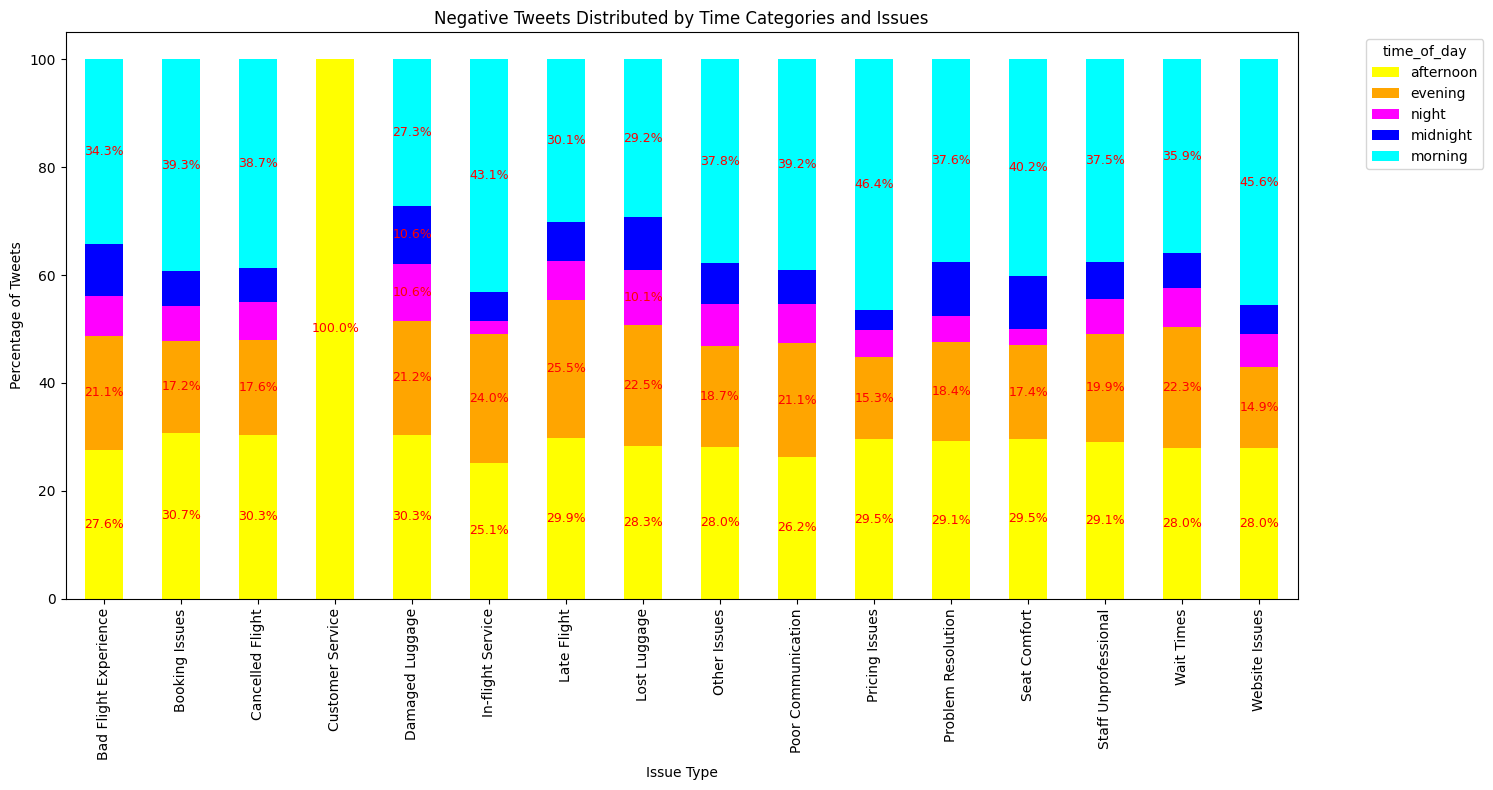

In [29]:
#issue distribution by time
# Re-calculate hour_dist to ensure a clean state for aggregation
hour_dist = df.groupby(['LLM_reason','hour'])['tweet_id'].count().unstack()
hour_percent_original = hour_dist.div(hour_dist.sum(axis=1), axis=0) * 100

# Create a new DataFrame for time categories
time_category_percent = pd.DataFrame({
    'afternoon': hour_percent_original.iloc[:, 12:17].sum(axis=1),
    'evening': hour_percent_original.iloc[:, 17:21].sum(axis=1),
    'night': hour_percent_original.iloc[:, 21:24].sum(axis=1),
    'midnight': hour_percent_original.iloc[:, 0:5].sum(axis=1),
    'morning': hour_percent_original.iloc[:, 5:12].sum(axis=1)
})

# Display the aggregated percentages
display(time_category_percent)

# Mapping hours 0-23 to their respective colors
day_palette = {'afternoon':'yellow','evening':'orange', 'night':'magenta','midnight':'blue','morning':'cyan' } # Corrected 'late_night' to 'midnight'

## visualization
### Issues by Hour
fig, ax = plt.subplots(figsize=(15,8))
time_category_percent.plot(kind='bar', stacked=True, ax=ax, color = [day_palette[col] for col in time_category_percent.columns]) # Plot the aggregated data
ax.set_title('Negative Tweets Distributed by Time Categories and Issues') # Updated title for clarity
ax.set_xlabel("Issue Type") # Updated xlabel as the x-axis represents issues
ax.set_ylabel("Percentage of Tweets")
ax.legend(title="time_of_day", bbox_to_anchor=(1.05, 1), loc='upper left')
#### Add data labels only if >10%
for p in ax.patches: # Iterate over patches of the current ax
    width, height = p.get_width(), p.get_height()
    if height > 10:  # show only if segment >10%
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2
        ax.text(x, y, f'{height:.1f}%', ha='center', va='center', fontsize=9, color='red') # Use ax.text
plt.tight_layout()
plt.show()

## Step 3: Emotion Classification Using a Pretrained Transformer

In [30]:
#create emotions pipeline
emotion_classifier = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    top_k=None,
    truncation=True,
    max_length=512
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [31]:
# classify each tweet into one of seven emotions: anger, sadness, joy, fear, disgust, surprise,
# or neutral using the pretrained transformer model
# Load cache
if os.path.exists(CLASS_PATH):
    with open(CLASS_PATH, "r") as f:
        cache = json.load(f)
else:
    cache = {}


texts_to_classify = df['clean_text'].tolist()

batch_size = 100
all_results = []

for i in tqdm(range(0, len(texts_to_classify), batch_size)):
    batch = texts_to_classify[i:i+batch_size]
    batch = [text if text.strip() else "neutral text" for text in batch]

    batch_results = []

    texts_to_run = []
    indices_to_run = []

    # Check cache first
    for idx, text in enumerate(batch):
        if text in cache:
            batch_results.append(cache[text])
        else:
            texts_to_run.append(text)
            indices_to_run.append(idx)
            batch_results.append(None)

    # Run model only for uncached texts
    if texts_to_run:
        model_results = emotion_classifier(texts_to_run)

        for j, result in enumerate(model_results):
            original_idx = indices_to_run[j]
            batch_results[original_idx] = result
            cache[texts_to_run[j]] = result

    all_results.extend(batch_results)

# Save cache
with open(CLASS_PATH, "w") as f:
    json.dump(cache, f)

# Extract top emotion
emotions = []
confidences = []

for result in all_results:
    top = max(result, key=lambda x: x['score'])
    emotions.append(top['label'])
    confidences.append(top['score'])

# Add to dataframe
df['emotion'] = emotions
df['emotion_confidence'] = confidences

100%|██████████| 145/145 [01:40<00:00,  1.45it/s]


/tmp/ipython-input-3058721998.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(


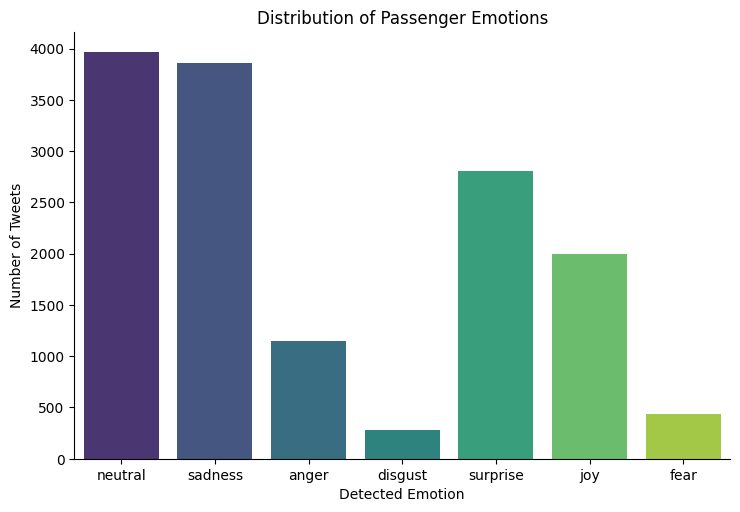

In [56]:
#emotions distribution
emotions_df = df.groupby('emotion')['tweet_id'].count()
emotions_df
sns.catplot(
    data=df,
    x='emotion',
    kind='count',
    palette='viridis',
    height=5,
    aspect=1.5
)

plt.title('Distribution of Passenger Emotions')
plt.ylabel('Number of Tweets')
plt.xlabel('Detected Emotion')
plt.show()

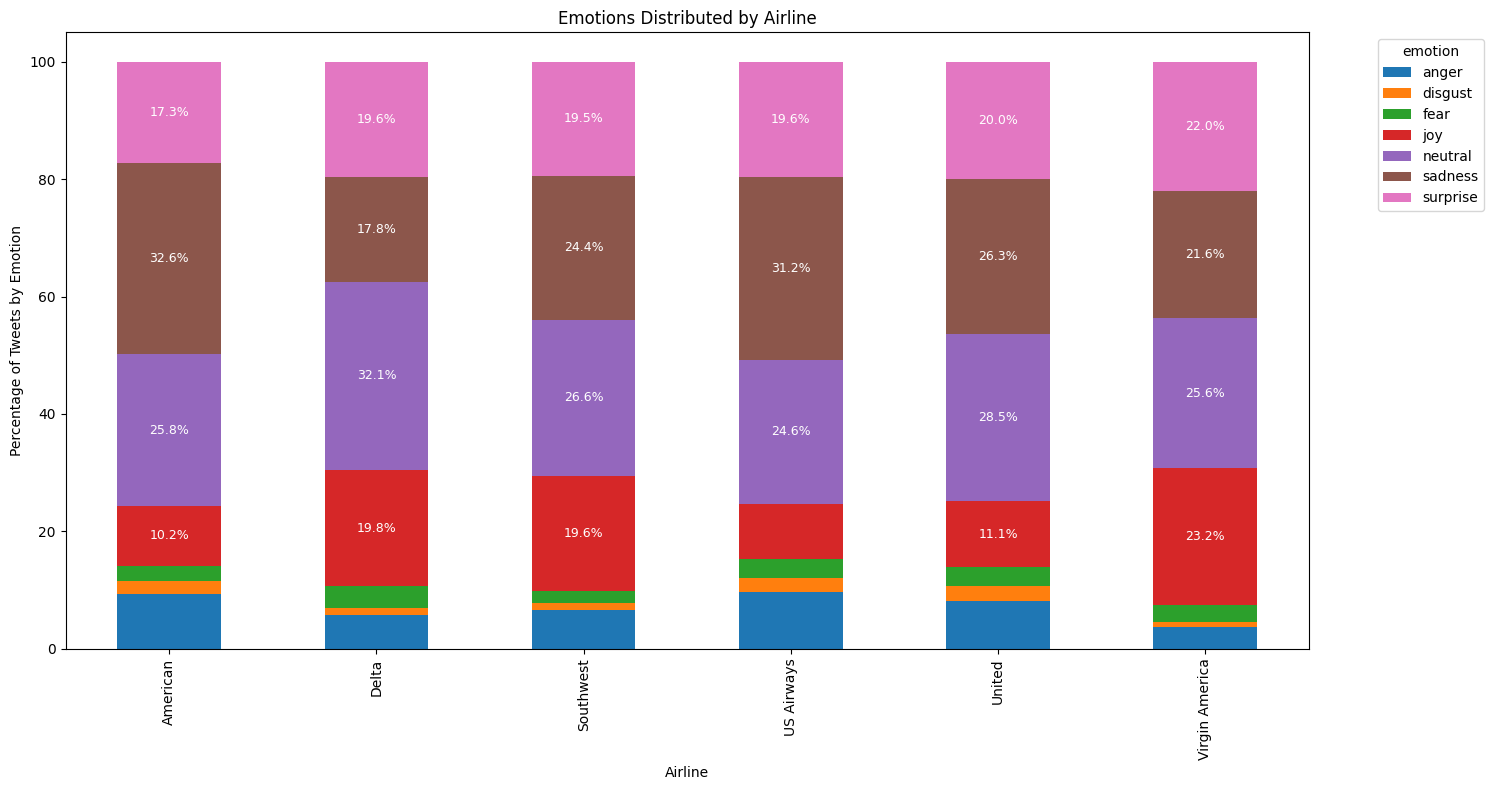

In [32]:
# analyze the emotional landscape of the dataset by examining how
# emotions vary across airlines, across time of day, and across reason categories
airline_emot = df.groupby(['airline','emotion'])['tweet_id'].count().unstack()
airlineemo_percent = airline_emot.div(airline_emot.sum(axis=1), axis=0) * 100
time_emot = df.groupby(['hour','emotion'])['tweet_id'].count().unstack()
timeemo_percent = time_emot.div(time_emot.sum(axis=1), axis=0) * 100
reason_emot = df.groupby(['LLM_reason','emotion'])['tweet_id'].count().unstack()
reasonemo_percent = reason_emot.div(reason_emot.sum(axis=1), axis=0) * 100
### visualizations
# Emotions by Airline
fig, ax = plt.subplots(figsize=(15,8))
airlineemo_percent.plot(kind='bar', stacked=True, ax=ax) # Plot the aggregated data
ax.set_title('Emotions Distributed by Airline') # Updated title for clarity
ax.set_xlabel("Airline") # Updated xlabel as the x-axis represents issues
ax.set_ylabel("Percentage of Tweets by Emotion")
ax.legend(title="emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
#### Add data labels only if >10%
for p in ax.patches: # Iterate over patches of the current ax
    width, height = p.get_width(), p.get_height()
    if height > 10:  # show only if segment >10%
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2
        ax.text(x, y, f'{height:.1f}%', ha='center', va='center', fontsize=9, color='white') # Use ax.text
plt.tight_layout()
plt.show()

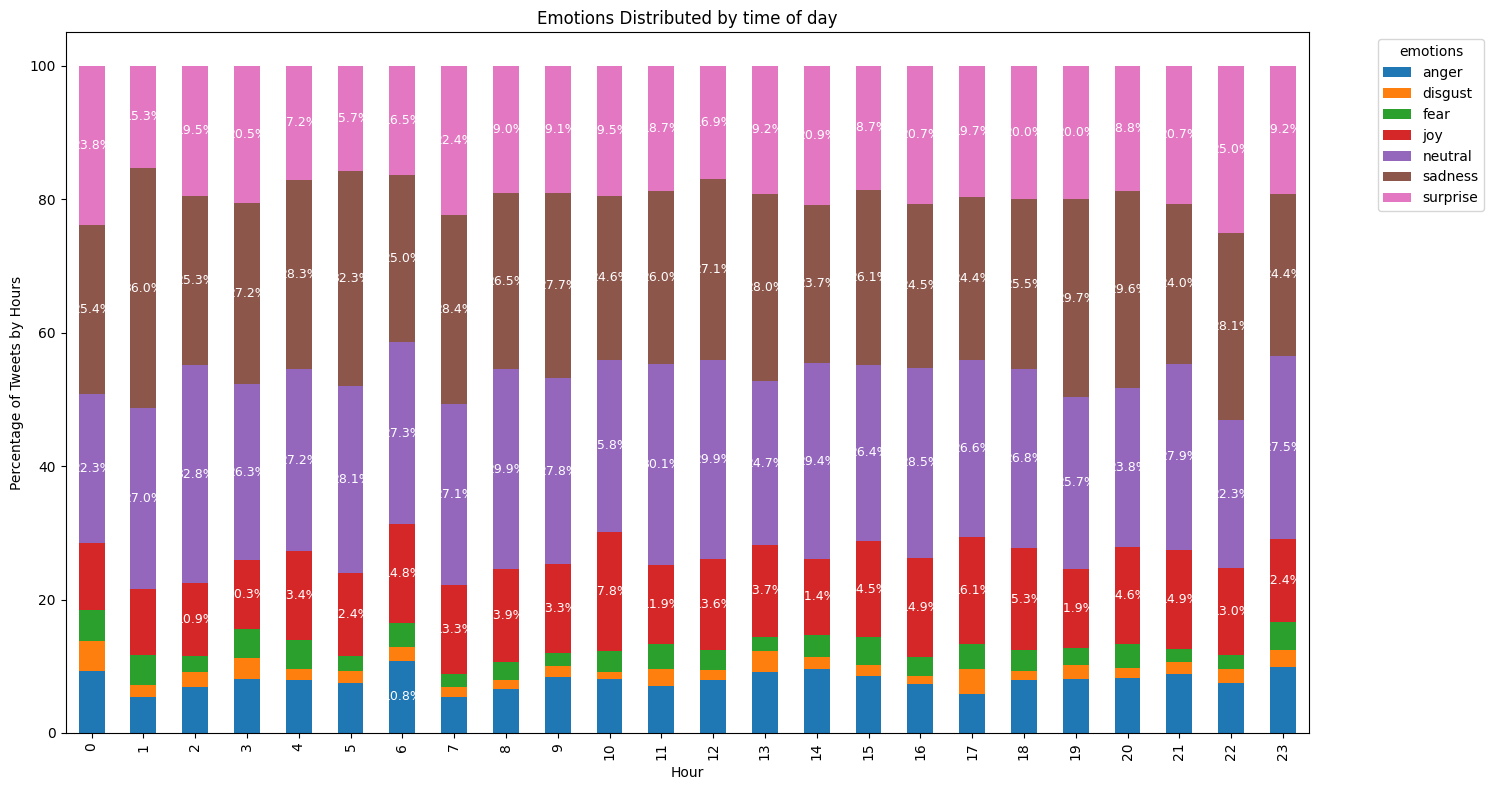

In [33]:
# Emotions by time
fig, ax = plt.subplots(figsize=(15,8))
timeemo_percent.plot(kind='bar', stacked=True, ax=ax) # Plot the aggregated data
ax.set_title('Emotions Distributed by time of day') # Updated title for clarity
ax.set_xlabel("Hour") # Updated xlabel as the x-axis represents issues
ax.set_ylabel("Percentage of Tweets by Hours")
ax.legend(title="emotions", bbox_to_anchor=(1.05, 1), loc='upper left')
#### Add data labels only if >10%
for p in ax.patches: # Iterate over patches of the current ax
    width, height = p.get_width(), p.get_height()
    if height > 10:  # show only if segment >10%
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2
        ax.text(x, y, f'{height:.1f}%', ha='center', va='center', fontsize=9, color='white') # Use ax.text
plt.tight_layout()
plt.show()

,afternoon,evening,night,midnight,morning
emotion,,,,,
anger,31.124673,18.134263,6.887533,6.713165,37.140366
disgust,28.113879,22.064057,6.761566,8.896797,34.163701
fear,29.587156,20.412844,5.045872,9.403670,35.550459
joy,28.234704,20.260782,6.318957,5.767302,39.418255
neutral,29.195054,18.092354,6.005551,6.939187,39.767853
sadness,28.008299,19.528008,6.016598,7.313278,39.133817
surprise,28.663102,19.465241,7.094474,6.809269,37.967914


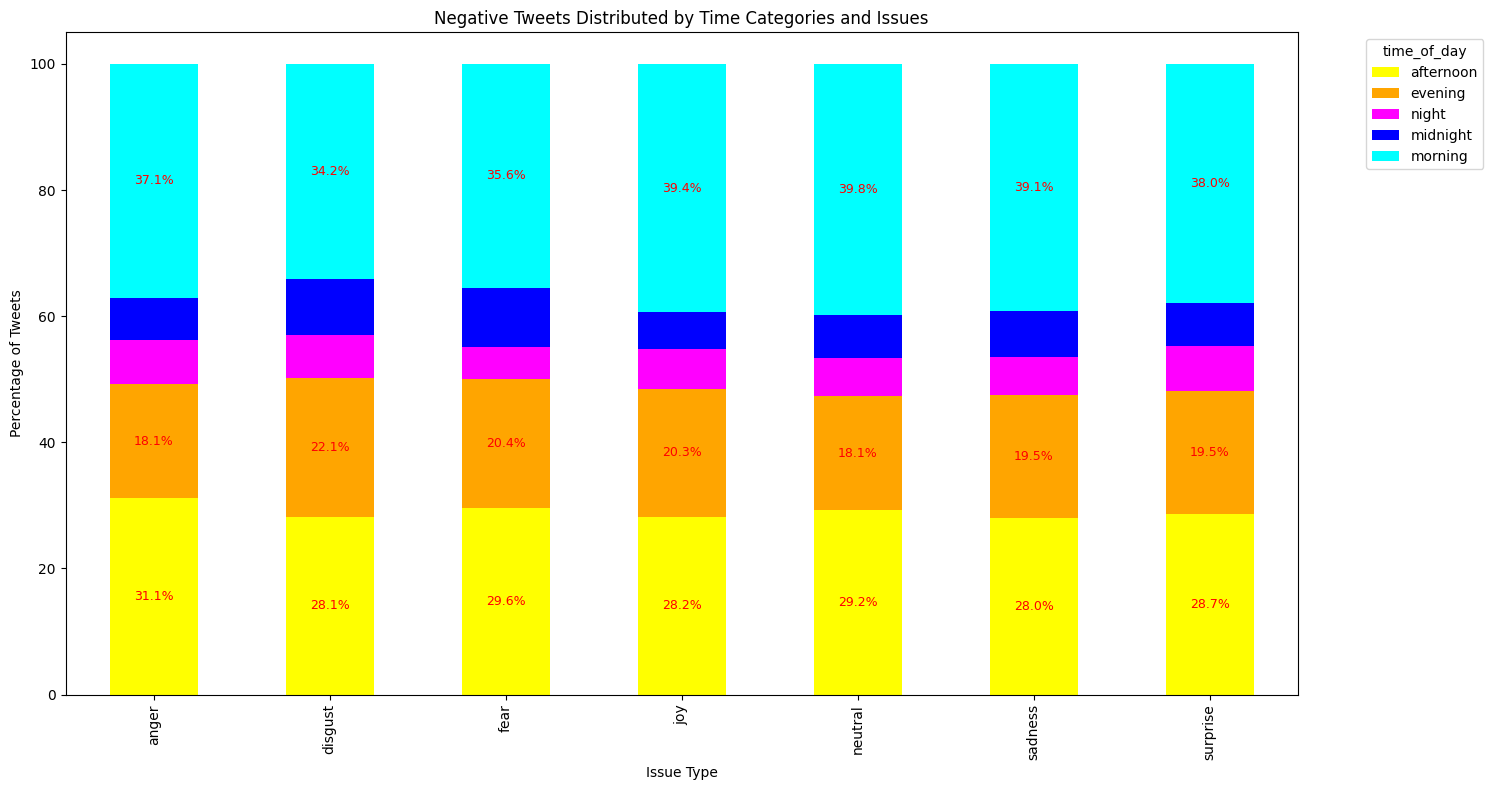

In [59]:
#emotion distribution by time
# Re-calculate hour_dist to ensure a clean state for aggregation
hour_emo = df.groupby(['emotion','hour'])['tweet_id'].count().unstack()
hour_emo_percent = hour_emo.div(hour_emo.sum(axis=1), axis=0) * 100

# Create a new DataFrame for time categories
time_emo_percent = pd.DataFrame({
    'afternoon': hour_emo_percent.iloc[:, 12:17].sum(axis=1),
    'evening': hour_emo_percent.iloc[:, 17:21].sum(axis=1),
    'night': hour_emo_percent.iloc[:, 21:24].sum(axis=1),
    'midnight': hour_emo_percent.iloc[:, 0:5].sum(axis=1),
    'morning': hour_emo_percent.iloc[:, 5:12].sum(axis=1)
})

# Display the aggregated percentages
display(time_emo_percent)

# Mapping hours 0-23 to their respective colors
day_palette = {'afternoon':'yellow','evening':'orange', 'night':'magenta','midnight':'blue','morning':'cyan' } # Corrected 'late_night' to 'midnight'

## visualization
### Issues by Hour
fig, ax = plt.subplots(figsize=(15,8))
time_emo_percent.plot(kind='bar', stacked=True, ax=ax, color = [day_palette[col] for col in time_emo_percent.columns]) # Plot the aggregated data
ax.set_title('Negative Tweets Distributed by Time Categories and Issues') # Updated title for clarity
ax.set_xlabel("Issue Type") # Updated xlabel as the x-axis represents issues
ax.set_ylabel("Percentage of Tweets")
ax.legend(title="time_of_day", bbox_to_anchor=(1.05, 1), loc='upper left')
#### Add data labels only if >10%
for p in ax.patches: # Iterate over patches of the current ax
    width, height = p.get_width(), p.get_height()
    if height > 10:  # show only if segment >10%
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2
        ax.text(x, y, f'{height:.1f}%', ha='center', va='center', fontsize=9, color='red') # Use ax.text
plt.tight_layout()
plt.show()

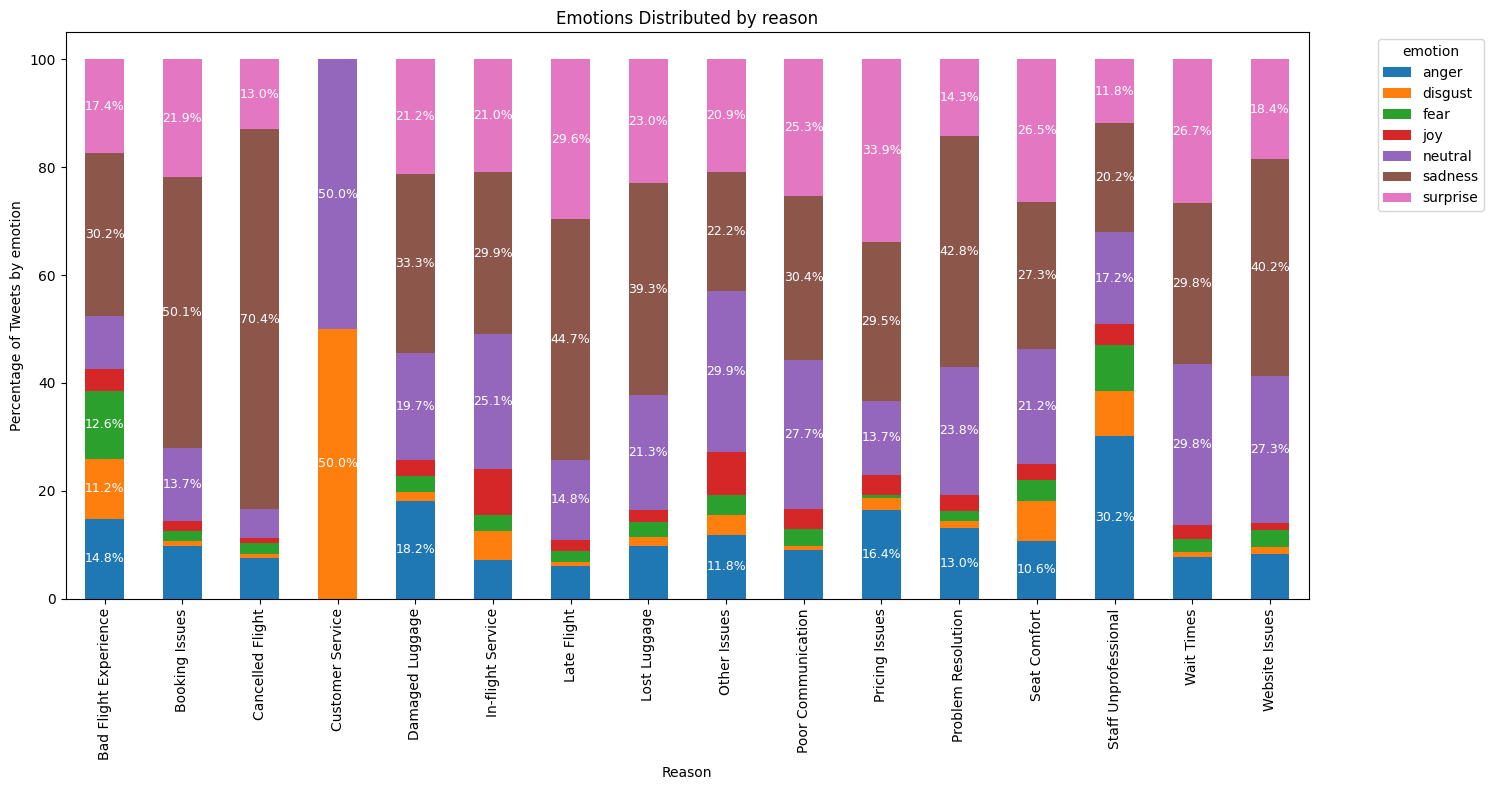

In [34]:
# Emotions by reason
fig, ax = plt.subplots(figsize=(15,8))
reasonemo_percent.plot(kind='bar', stacked=True, ax=ax) # Plot the aggregated data
ax.set_title('Emotions Distributed by reason') # Updated title for clarity
ax.set_xlabel("Reason") # Updated xlabel as the x-axis represents issues
ax.set_ylabel("Percentage of Tweets by emotion")
ax.legend(title="emotion", bbox_to_anchor=(1.05, 1), loc='upper left')
#### Add data labels only if >10%
for p in ax.patches: # Iterate over patches of the current ax
    width, height = p.get_width(), p.get_height()
    if height > 10:  # show only if segment >10%
        x = p.get_x() + width / 2
        y = p.get_y() + height / 2
        ax.text(x, y, f'{height:.1f}%', ha='center', va='center', fontsize=9, color='white') # Use ax.text
plt.tight_layout()
plt.show()

In [35]:
# Include representative tweets for each emotion to validate that the model output aligns with human intuition
n_examples = 5

rep_tweets = (
    df.sort_values("emotion_confidence", ascending=False).groupby("emotion").head(n_examples)[["emotion", "emotion_confidence", "clean_text"]])

rep_tweets

,emotion,emotion_confidence,clean_text
13897,anger,0.995286,i understand i'm feeling cranky i called aa's ...
4163,anger,0.994113,i am furious you're firm is a disgrace despite...
9102,joy,0.994080,i really feel like your company needs evaluate...
12814,joy,0.994057,i'll try to have a great week once i receive it
22,joy,0.993984,i love the hipster innovation you are a feel g...
578,joy,0.993928,i flew united last month and the experience wa...
3413,anger,0.993746,i must stop my relationship with you you've be...
12220,joy,0.993573,i still think american airlines is greati woul...
11149,sadness,0.993276,i feel sorry for aa
10451,fear,0.993243,nervous for flight tomrw out of key west not f...


## Step 4: Language & Expression Analysis

In [36]:
# How passengers express emotions through linguistic and stylistic patterns in their tweets
## tweet length

# Calculate text features
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
df[['text', 'text_length', 'word_count']].head()

,text,text_length,word_count
0,@VirginAmerica What @dhepburn said.,35,4
1,@VirginAmerica plus you've added commercials t...,72,9
2,@VirginAmerica I didn't today... Must mean I n...,71,12
3,@VirginAmerica it's really aggressive to blast...,126,17
4,@VirginAmerica and it's a really big bad thing...,55,10


In [37]:
## frequency of direct @mentions
def count_mentions(text):
  return len(re.findall(r'@\w+', text))

df['mention_count'] = df['text'].apply(count_mentions)
mention = df.groupby('emotion')['mention_count'].sum()
mention

,mention_count
emotion,
anger,1311
disgust,314
fear,480
joy,2311
neutral,4553
sadness,4235
surprise,3124


In [38]:
## emoji usage by emotion state
def extract_emojis(text):
    return [c for c in text if emoji.is_emoji(c)]

df['emojis_used'] = df['text'].apply(extract_emojis)
df['emoji_count'] = df['emojis_used'].apply(len)
emoji = df.groupby('emotion')['emoji_count'].sum()
emoji

,emoji_count
emotion,
anger,38
disgust,8
fear,41
joy,245
neutral,228
sadness,177
surprise,224


In [40]:
##  use of emphasis or capitalization by emotion state
def extract_cap(text):
    return [c for c in text if c.isupper()]

df['cap_used'] = df['text'].apply(extract_cap)
df['cap_count'] = df['cap_used'].apply(len)
cap = df.groupby('emotion')['cap_count'].sum()
cap

,cap_count
emotion,
anger,6589
disgust,1465
fear,2630
joy,11867
neutral,21282
sadness,24597
surprise,17186


In [41]:
## most common unigrams by emotion state
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def get_top_unigrams(corpus, n=10):
    # Flatten list of words, lowercase, and remove non-alphabetic/stopwords
    words = [word.lower() for text in corpus for word in str(text).split()
             if word.isalpha() and word.lower() not in stop_words]
    return Counter(words).most_common(n)

# Apply to each emotion group
unigrams_by_emotion = df.groupby('emotion')['text'].apply(get_top_unigrams)

for emotion, top_words in unigrams_by_emotion.items():
    print(f"Emotion: {emotion} | Key Unigrams: {top_words}")

Emotion: anger | Key Unigrams: [('flight', 197), ('get', 91), ('customer', 90), ('rude', 80), ('service', 80), ('cancelled', 63), ('us', 59), ('hold', 58), ('time', 57), ('worst', 55)]
Emotion: disgust | Key Unigrams: [('worst', 89), ('customer', 50), ('service', 47), ('ever', 32), ('airline', 29), ('flight', 29), ('guys', 21), ('experience', 18), ('worse', 14), ('us', 13)]
Emotion: fear | Key Unigrams: [('flight', 109), ('customer', 57), ('horrible', 56), ('service', 56), ('terrible', 55), ('get', 30), ('experience', 24), ('time', 21), ('cancelled', 20), ('gate', 20)]
Emotion: joy | Key Unigrams: [('thank', 376), ('thanks', 264), ('flight', 240), ('great', 178), ('love', 115), ('would', 107), ('service', 105), ('customer', 99), ('get', 89), ('good', 82)]
Emotion: neutral | Key Unigrams: [('flight', 572), ('get', 284), ('please', 209), ('us', 168), ('would', 160), ('thanks', 156), ('time', 152), ('hold', 141), ('need', 140), ('still', 136)]
Emotion: sadness | Key Unigrams: [('flight', 

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [42]:
## most common bigrams by emotion state
def get_top_bigrams(corpus, n=10):
    # Flatten list of pairs, lowercase, and remove non-alphabetic/stopwords
    words = [word.lower() for text in corpus for word in str(text).split()
             if word.isalpha() and word.lower() not in stop_words]
    bigram_list = list(zip(words,words[1:]))
    return Counter(bigram_list).most_common(n)

# Apply to each emotion group
bigrams_by_emotion = df.groupby('emotion')['text'].apply(get_top_bigrams)

for emotion, top_pairs in bigrams_by_emotion.items():
    formatted_pairs = [f"{a} {b}" for (a, b), count in top_pairs]
    print(f"Emotion: {emotion} | Key Bigrams: {formatted_pairs}")

Emotion: anger | Key Bigrams: ['customer service', 'cancelled flightled', 'gate agent', 'worst customer', 'worst airline', 'late flight', 'flight cancelled', 'let us', 'cancelled flight', 'flight attendants']
Emotion: disgust | Key Bigrams: ['customer service', 'worst customer', 'worst airline', 'airline ever', 'service ever', 'worst experience', 'experience ever', 'cancelled flighted', 'getting worse', 'first class']
Emotion: fear | Key Bigrams: ['customer service', 'terrible customer', 'cancelled flightled', 'horrible customer', 'terrible service', 'horrible experience', 'flight delayed', 'terrible experience', 'flight booking', 'booking problems']
Emotion: joy | Key Bigrams: ['customer service', 'thank thank', 'looking forward', 'thank much', 'great flight', 'would love', 'thank great', 'great job', 'great customer', 'would like']
Emotion: neutral | Key Bigrams: ['customer service', 'late flight', 'booking problems', 'still waiting', 'let us', 'flight booking', 'make sure', 'call ba

In [50]:
df[df['LLM_reason']=="Booking Issues"]['clean_text'].head(50)

,clean_text
24,you guys messed up my seating i reserved seati...
30,hi! i just bked a cool birthday trip with you ...
41,hey first time flyer next week - excited! but ...
85,im having trouble adding this flight my wife b...
139,why can't we book seats on your flights when w...
146,question is it not possible to book a seat for...
243,we're on flight 910 vegas to boston today chec...
444,i tried that you offered to charge me an addit...
484,grouping virgin in with the others now bos wea...
487,trying to make the change in advance not just ...


In [60]:
# Include representative tweets for each emotion to validate that the model output aligns with human intuition
n_examples = 7

rep_tweets = (
    df.sort_values("emotion_confidence", ascending=True).groupby("emotion").head(n_examples)[["emotion", "emotion_confidence", "clean_text"]])

rep_tweets

,emotion,emotion_confidence,clean_text
4884,surprise,0.217661,yes please!
808,fear,0.230145,please help i am in ethiopia adopting a two ye...
4361,sadness,0.230332,i used to always fly southwest
3693,neutral,0.243768,a report was filed with the airport police on ...
10647,sadness,0.243931,i've been on hold for 75 minutes waiting to ta...
10335,neutral,0.245759,question is why flight took off at all now a f...
5475,joy,0.250660,flt 947 emer stop in albuquer for a heart cond...
14509,neutral,0.252650,the personal touch you're known for aa other c...
13216,anger,0.252930,i totally agree you get the automatic phone at...
13357,neutral,0.254917,when do you anticipate decisions for cancelled...
